# 6CS012 - Part III: Hotel Review Rating Classification
### Text Classification using Simple RNN, LSTM, and Word2Vec Embeddings
**Dataset placeholder:** `hotel_review.csv`  
**Text column:** `Review` | **Label column:** `Rating`  
**Task:** 5-class rating classification using ratings `1, 2, 3, 4, 5`  
**Framework:** Keras (TensorFlow) | scikit-learn

## Section 0 - Setup & Imports

In [87]:



import os, re, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Required NLTK resources for stopword removal and lemmatization.
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.19.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## Section 1 - Data Understanding, Analysis & Visualization
*(Task 4.5.1)*

The dataset is expected to contain hotel review text in `Review` and rating labels in `Rating`.

In [88]:

# -- Paths and dataset columns ---------------------------------------------
# Keep this as a placeholder. Update this path manually when moving the dataset.
DATA_PATH = Path('/kaggle/input/datasets/aryamadityamathema/hotel-review-dataset/Hotel Review Dataset/Hotel_Reviews.csv')

TEXT_COLUMN = 'Review'
LABEL_COLUMN = 'Rating'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Place the CSV here or update DATA_PATH before running.'
    )

raw_data = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {raw_data.shape}')
print('Columns:', list(raw_data.columns))
raw_data.head()

Dataset shape: (20491, 2)
Columns: ['Review', 'Rating']


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [89]:

# -- Select required columns and remove missing values ----------------------
required_columns = [TEXT_COLUMN, LABEL_COLUMN]
missing_columns = [col for col in required_columns if col not in raw_data.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

data = raw_data[required_columns].dropna().copy()
data[TEXT_COLUMN] = data[TEXT_COLUMN].astype(str)
data[LABEL_COLUMN] = data[LABEL_COLUMN].astype(int)

print(f'Rows after dropping missing values: {len(data)}')
print(f'Unique ratings: {sorted(data[LABEL_COLUMN].unique())}')
print('\nRating distribution:')
print(data[LABEL_COLUMN].value_counts().sort_index())

data.head()

Rows after dropping missing values: 20491
Unique ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


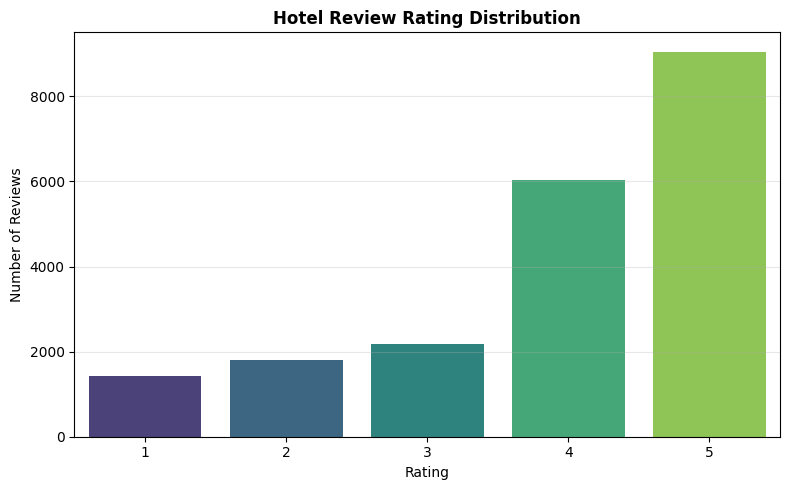

In [90]:

# -- Rating distribution plot ----------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x=LABEL_COLUMN, order=sorted(data[LABEL_COLUMN].unique()), palette='viridis')
plt.title('Hotel Review Rating Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 2 - Text Cleaning Pipeline
*(Task 4.5.1)*

Cleaning follows the Week 8 and Week 9 preprocessing pattern: lowercase, remove URLs, mentions, hashtags, numbers, special characters, remove stopwords, and lemmatize tokens.

In [91]:

# -- Text cleaning helper functions ----------------------------------------
lemmatizer = WordNetLemmatizer()

# Keep negation terms because they are important for sentiment and rating prediction.
stop_words = set(stopwords.words('english')) - {'no', 'nor', 'not'}

def expand_contractions(text):
    """Expand common English contractions before removing punctuation."""
    text = re.sub(r"won['’]t", 'will not', text)
    text = re.sub(r"can['’]t", 'can not', text)
    text = re.sub(r"n['’]t", ' not', text)
    text = re.sub(r"['’]re", ' are', text)
    text = re.sub(r"['’]s", ' is', text)
    text = re.sub(r"['’]d", ' would', text)
    text = re.sub(r"['’]ll", ' will', text)
    text = re.sub(r"['’]ve", ' have', text)
    text = re.sub(r"['’]m", ' am', text)
    return text


def clean_text(text):
    """Clean one review and return a lemmatized text string."""
    text = str(text).lower()
    text = expand_contractions(text)

    # Remove URLs, user mentions, hashtags, numbers, and non-letter characters.
    text = re.sub(r'http\S+|www\.\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize words to their base verb form.
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word, pos='v') for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [92]:

# -- Apply cleaning pipeline ------------------------------------------------
data['cleaned_text'] = data[TEXT_COLUMN].apply(clean_text)

sample_view = data[[TEXT_COLUMN, 'cleaned_text', LABEL_COLUMN]].head(5)
sample_view

,Review,cleaned_text,Rating
0,nice hotel expensive parking got good deal sta...,nice hotel expensive park get good deal stay h...,4
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...,3
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,5
4,"great stay great stay, went seahawk game aweso...",great stay great stay go seahawk game awesome ...,5


In [93]:

# -- Check for empty reviews after cleaning --------------------------------
empty_count = (data['cleaned_text'].str.len() == 0).sum()
print(f'Empty cleaned reviews: {empty_count}')

# Keep empty strings as valid all-padding sequences; no rows are removed here.

Empty cleaned reviews: 0


---
## Section 3 - Cleaned Text Visualization
*(Task 4.5.1)*

,word,count
0,not,50724
1,hotel,49885
2,room,47783
3,stay,28556
4,great,21484
5,good,17424
6,staff,16806
7,time,13017
8,nice,12647
9,no,11853


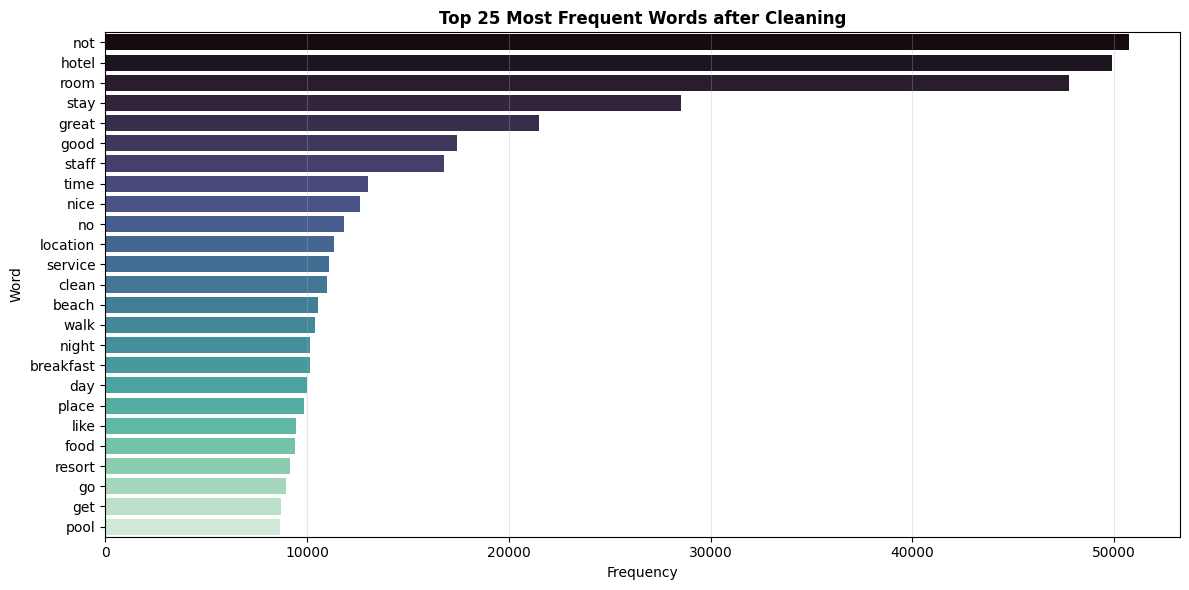

In [94]:

# -- Most frequent words in cleaned reviews --------------------------------
all_words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(25), columns=['word', 'count'])

display(top_words.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x='count', y='word', palette='mako')
plt.title('Top 25 Most Frequent Words after Cleaning', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 4 - Train-Test Split, Tokenization and Padding
*(Task 4.5.1)*

Workflow: split first, fit tokenizer only on training text, then convert text to padded sequences.

In [95]:

# -- Encode labels for 5-class classification ------------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(data[LABEL_COLUMN])

class_values = list(label_encoder.classes_)
class_names = [f'Rating {rating}' for rating in class_values]
NUM_CLASSES = len(class_values)

print(f'Encoded classes: {dict(zip(class_values, range(NUM_CLASSES)))}')
print(f'Number of classes: {NUM_CLASSES}')

Encoded classes: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}
Number of classes: 5


In [96]:

# -- 80/20 train-test split -------------------------------------------------
X_train_text, X_test_text, y_train_full, y_test = train_test_split(
    data['cleaned_text'],
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Preserve original test reviews for later error analysis.
test_original_reviews = data.loc[X_test_text.index, TEXT_COLUMN].reset_index(drop=True)
test_cleaned_reviews = X_test_text.reset_index(drop=True)

print(f'Train text count: {len(X_train_text)}')
print(f'Test text count : {len(X_test_text)}')

Train text count: 16392
Test text count : 4099


In [97]:

# -- Keras tokenization -----------------------------------------------------
MAX_WORDS = 10000
OOV_TOKEN = '<OOV>'

# Fit only on the training text to avoid information leakage.
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f'Full tokenizer vocabulary size: {len(tokenizer.word_index) + 1}')
print(f'Vocabulary used by models     : {VOCAB_SIZE}')

Full tokenizer vocabulary size: 37807
Vocabulary used by models     : 10000


In [98]:

# -- Percentile-based sequence padding -------------------------------------
sequence_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 1)

X_train_pad_full = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f'95th percentile padding length: {MAX_LEN}')
print(f'X_train_pad_full shape       : {X_train_pad_full.shape}')
print(f'X_test_pad shape             : {X_test_pad.shape}')

95th percentile padding length: 265
X_train_pad_full shape       : (16392, 265)
X_test_pad shape             : (4099, 265)


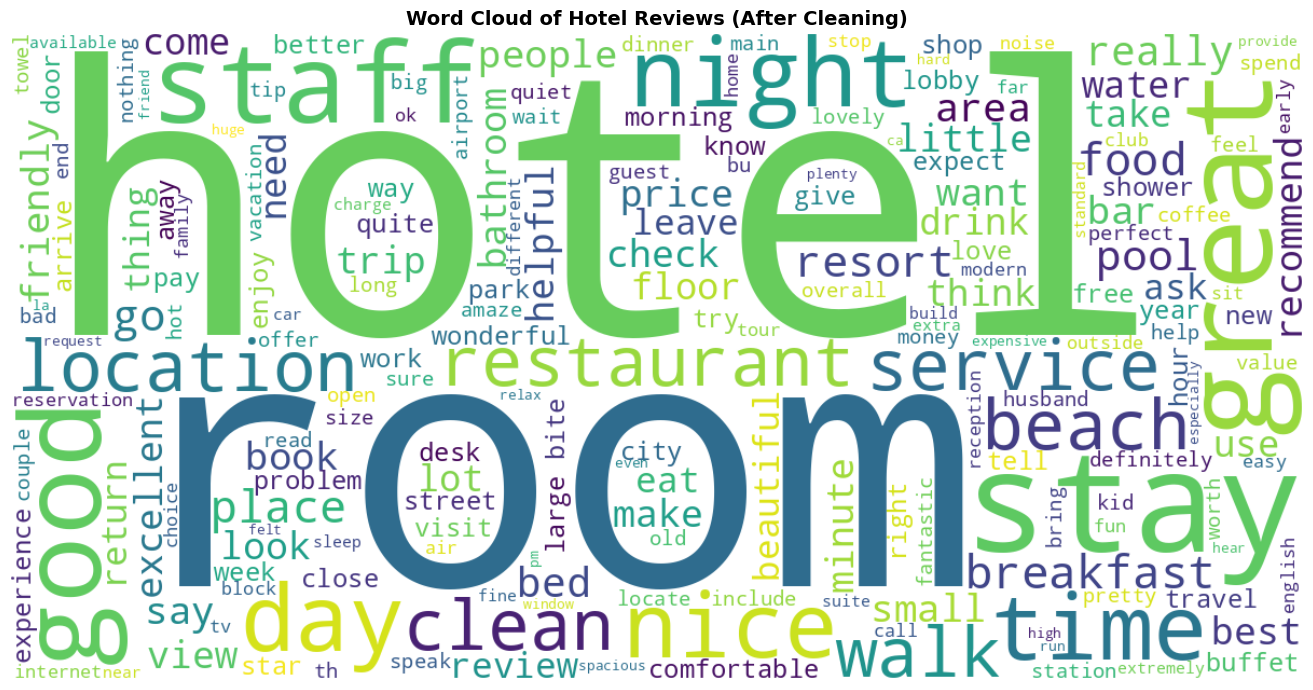

Word cloud generated successfully!


In [99]:
from wordcloud import WordCloud

# Generate word cloud from cleaned text
all_cleaned_text = ' '.join(data['cleaned_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',
    collocations=False
).generate(all_cleaned_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Hotel Reviews (After Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

print("Word cloud generated successfully!")

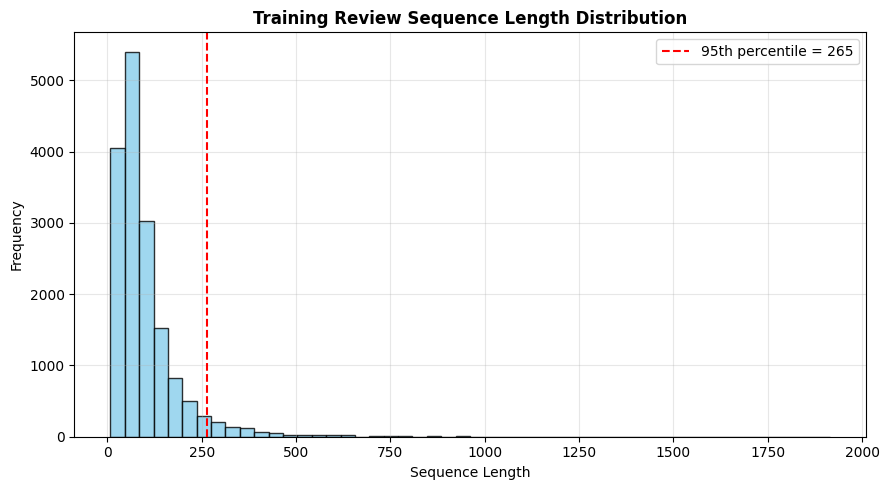

In [100]:

# -- Sequence length distribution ------------------------------------------
plt.figure(figsize=(9, 5))
plt.hist(sequence_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th percentile = {MAX_LEN}')
plt.title('Training Review Sequence Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:

# -- Validation split from the training set --------------------------------
X_train_pad, X_val_pad, y_train, y_val = train_test_split(
    X_train_pad_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print(f'Model train shape: {X_train_pad.shape}')
print(f'Validation shape : {X_val_pad.shape}')
print(f'Test shape       : {X_test_pad.shape}')

Model train shape: (13113, 265)
Validation shape : (3279, 265)
Test shape       : (4099, 265)


---
## Section 5 - Helper Functions for Training and Evaluation

In [102]:

# -- Common training configuration -----------------------------------------
EPOCHS = 10
BATCH_SIZE = 64
EMBEDDING_DIM = 128
RNN_UNITS = 64

results = []
model_registry = {}
history_registry = {}
predictions_by_model = {}


def get_callbacks(model_name):
    """Return early stopping and checkpoint callbacks for a model."""
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    return [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{safe_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]


def plot_history(history, title='', save=None):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs_range = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs_range, history.history['loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(epochs_range, history.history['val_loss'], 'r-o', ms=3, label='Validation')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history.history['accuracy'], 'b-o', ms=3, label='Train')
    axes[1].plot(epochs_range, history.history['val_accuracy'], 'r-o', ms=3, label='Validation')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def count_params(model):
    """Count total and trainable model parameters."""
    total_params = model.count_params()
    trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    return total_params, trainable_params


def evaluate_model(model, model_name, training_time):
    """Evaluate a model using accuracy, confusion matrix, and classification report."""
    test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    print(f'{model_name} - Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

    total_params, trainable_params = count_params(model)
    result = {
        'Model': model_name,
        'Test Loss': test_loss,
        'Test Accuracy': test_acc,
        'Training Time (min)': training_time / 60,
        'Total Params': total_params,
        'Trainable Params': trainable_params
    }
    return result, y_pred


def plot_confusion(y_true, y_pred, title, save=None):
    """Plot a confusion matrix for model predictions."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=class_names
    ).plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

---
## Section 6 - Model 1: Simple RNN with Trainable Embedding
*(Task 4.5.2 and 4.5.3)*

In [103]:

# -- Build Simple RNN model -------------------------------------------------
def build_simple_rnn_model():
    model = models.Sequential(name='simple_rnn_trainable_embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        mask_zero=True,
        name='embedding'
    ))
    model.add(layers.SimpleRNN(RNN_UNITS, name='simple_rnn'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

rnn_model = build_simple_rnn_model()
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "simple_rnn_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.4286 - loss: 1.3430 - val_accuracy: 0.5005 - val_loss: 1.0903
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6385 - loss: 0.9215 - val_accuracy: 0.4892 - val_loss: 1.1034
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8393 - loss: 0.5036 - val_accuracy: 0.4742 - val_loss: 1.3587
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9529 - loss: 0.1938 - val_accuracy: 0.4742 - val_loss: 1.6794
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


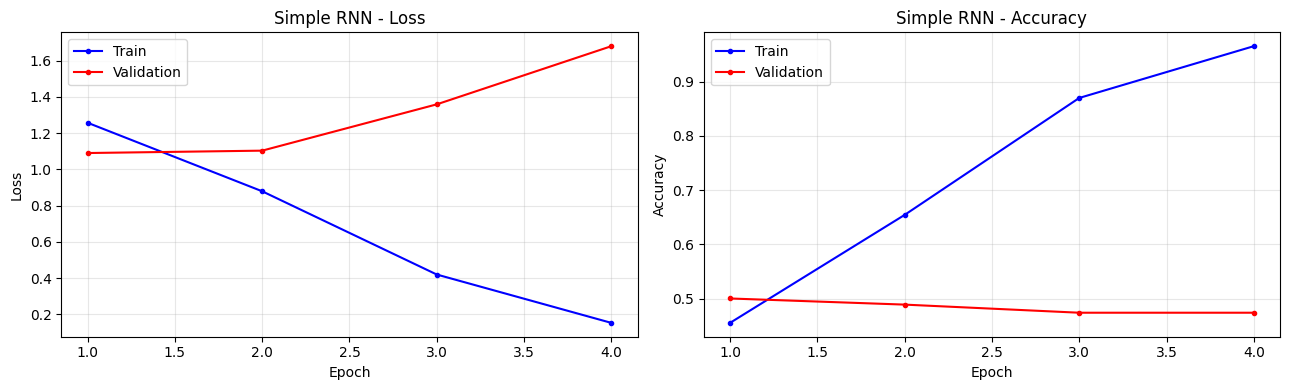

In [104]:

# -- Train Simple RNN model -------------------------------------------------
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks('Simple RNN'),
    verbose=1
)
rnn_training_time = time.time() - t0

plot_history(history_rnn, 'Simple RNN', 'simple_rnn_curves.png')

Simple RNN - Test Loss: 1.0756 | Test Accuracy: 0.5043

Classification Report:
              precision    recall  f1-score   support

    Rating 1     0.4084    0.6514    0.5020       284
    Rating 2     0.3333    0.1448    0.2019       359
    Rating 3     0.3846    0.0343    0.0630       437
    Rating 4     0.3653    0.0662    0.1121      1208
    Rating 5     0.5368    0.9580    0.6881      1811

    accuracy                         0.5043      4099
   macro avg     0.4057    0.3710    0.3134      4099
weighted avg     0.4433    0.5043    0.3962      4099



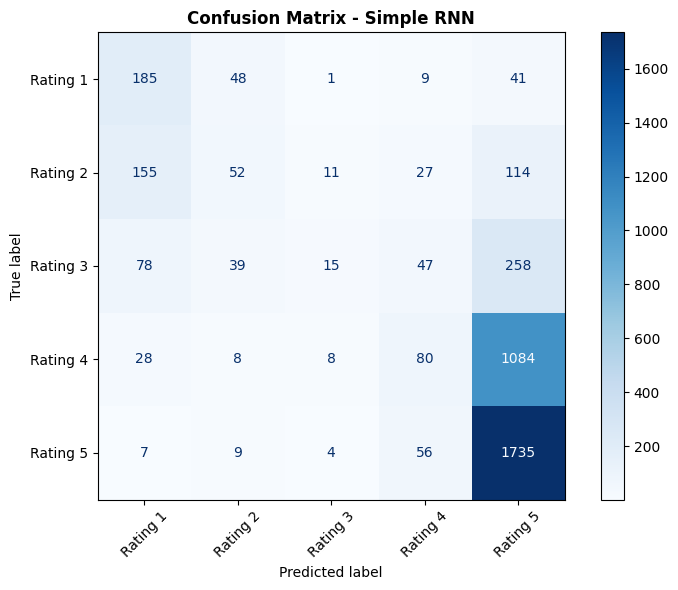

In [105]:

# -- Evaluate Simple RNN model ---------------------------------------------
rnn_result, y_pred_rnn = evaluate_model(rnn_model, 'Simple RNN', rnn_training_time)
results.append(rnn_result)
model_registry['Simple RNN'] = rnn_model
history_registry['Simple RNN'] = history_rnn
predictions_by_model['Simple RNN'] = y_pred_rnn

plot_confusion(y_test, y_pred_rnn, 'Confusion Matrix - Simple RNN', 'cm_simple_rnn.png')

---
## Section 7 - Model 2: LSTM with Trainable Embedding
*(Task 4.5.2 and 4.5.3)*

In [106]:

# -- Build LSTM model with trainable embedding -----------------------------
def build_lstm_model():
    model = models.Sequential(name='lstm_trainable_embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        mask_zero=True,
        name='embedding'
    ))
    model.add(layers.LSTM(RNN_UNITS, name='lstm'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

lstm_model = build_lstm_model()
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4527 - loss: 1.2850 - val_accuracy: 0.5715 - val_loss: 0.9668
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6024 - loss: 0.9025 - val_accuracy: 0.6002 - val_loss: 0.9103
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6829 - loss: 0.7387 - val_accuracy: 0.5947 - val_loss: 0.9386
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7285 - loss: 0.6561 - val_accuracy: 0.5956 - val_loss: 0.9969
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7794 - loss: 0.5576 - val_accuracy: 0.5660 - val_loss: 1.1460
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


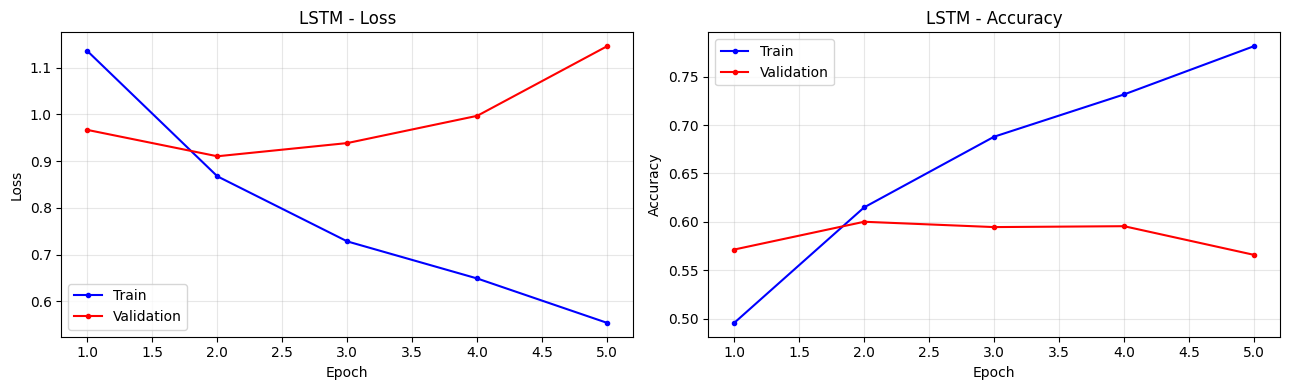

In [107]:

# -- Train LSTM model -------------------------------------------------------
t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks('LSTM'),
    verbose=1
)
lstm_training_time = time.time() - t0

plot_history(history_lstm, 'LSTM', 'lstm_curves.png')

LSTM - Test Loss: 0.9161 | Test Accuracy: 0.6014

Classification Report:
              precision    recall  f1-score   support

    Rating 1     0.6530    0.6162    0.6341       284
    Rating 2     0.4484    0.4234    0.4355       359
    Rating 3     0.4013    0.2838    0.3324       437
    Rating 4     0.4861    0.5654    0.5228      1208
    Rating 5     0.7486    0.7350    0.7417      1811

    accuracy                         0.6014      4099
   macro avg     0.5475    0.5247    0.5333      4099
weighted avg     0.6013    0.6014    0.5993      4099



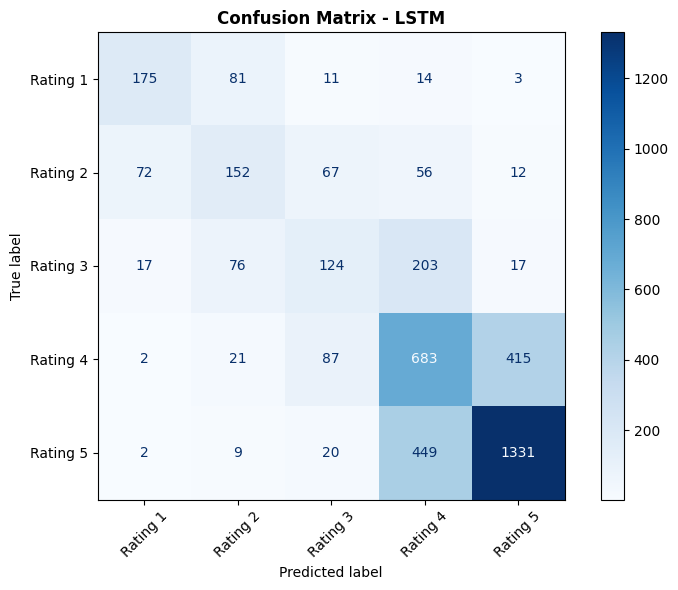

In [108]:

# -- Evaluate LSTM model ----------------------------------------------------
lstm_result, y_pred_lstm = evaluate_model(lstm_model, 'LSTM', lstm_training_time)
results.append(lstm_result)
model_registry['LSTM'] = lstm_model
history_registry['LSTM'] = history_lstm
predictions_by_model['LSTM'] = y_pred_lstm

plot_confusion(y_test, y_pred_lstm, 'Confusion Matrix - LSTM', 'cm_lstm.png')

---
## Section 8 - Model 3: LSTM with Pretrained Word2Vec/GloVe Embeddings
*(Task 4.5.2 and Appendix 6.1)*

This implementation uses `gensim.downloader` to load `glove-wiki-gigaword-50` and initialize the embedding layer.

In [109]:

# -- Load pretrained embedding model ---------------------------------------
# This requires gensim and internet access the first time it downloads the model.
try:
    import gensim.downloader as api
except ImportError as exc:
    raise ImportError('Install gensim before running this section: pip install gensim') from exc

PRETRAINED_EMBEDDING_NAME = 'glove-wiki-gigaword-50'
embedding_model = api.load(PRETRAINED_EMBEDDING_NAME)
WORD2VEC_DIM = embedding_model.vector_size

print(f'Loaded pretrained embedding: {PRETRAINED_EMBEDDING_NAME}')
print(f'Embedding dimension: {WORD2VEC_DIM}')

Loaded pretrained embedding: glove-wiki-gigaword-50
Embedding dimension: 50


In [110]:

# -- Build embedding matrix for tokenizer vocabulary -----------------------
embedding_matrix = np.zeros((VOCAB_SIZE, WORD2VEC_DIM))
matched_words = 0

for word, index in tokenizer.word_index.items():
    if index >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        matched_words += 1

coverage = matched_words / max(1, VOCAB_SIZE - 1)
print(f'Matched words: {matched_words:,} / {VOCAB_SIZE - 1:,}')
print(f'Embedding coverage: {coverage:.2%}')

Matched words: 9,459 / 9,999
Embedding coverage: 94.60%


In [111]:

# -- Build LSTM model with pretrained embedding ----------------------------
def build_lstm_word2vec_model():
    model = models.Sequential(name='lstm_pretrained_word2vec_embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        mask_zero=True,
        trainable=False,
        name='pretrained_embedding'
    ))
    model.add(layers.LSTM(RNN_UNITS, name='lstm'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', name='output'))
    return model

lstm_w2v_model = build_lstm_word2vec_model()
lstm_w2v_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_w2v_model.summary()

Model: "lstm_pretrained_word2vec_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ ?                      │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4146 - loss: 1.3720 - val_accuracy: 0.5078 - val_loss: 1.1070
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5272 - loss: 1.0841 - val_accuracy: 0.5395 - val_loss: 1.0299
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5464 - loss: 1.0172 - val_accuracy: 0.5633 - val_loss: 0.9923
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5689 - loss: 0.9737 - val_accuracy: 0.5825 - val_loss: 0.9472
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5824 - loss: 0.9379 - val_accuracy: 0.5938 - val_loss: 0.9146
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5950 - loss: 0.9036 - val_accuracy: 0.6038 - val_loss: 0.8989
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6085 - loss: 0.8882 - val_accuracy: 0.6014 - val_loss: 0.8920
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6248 - loss: 0.8508 - val_accu

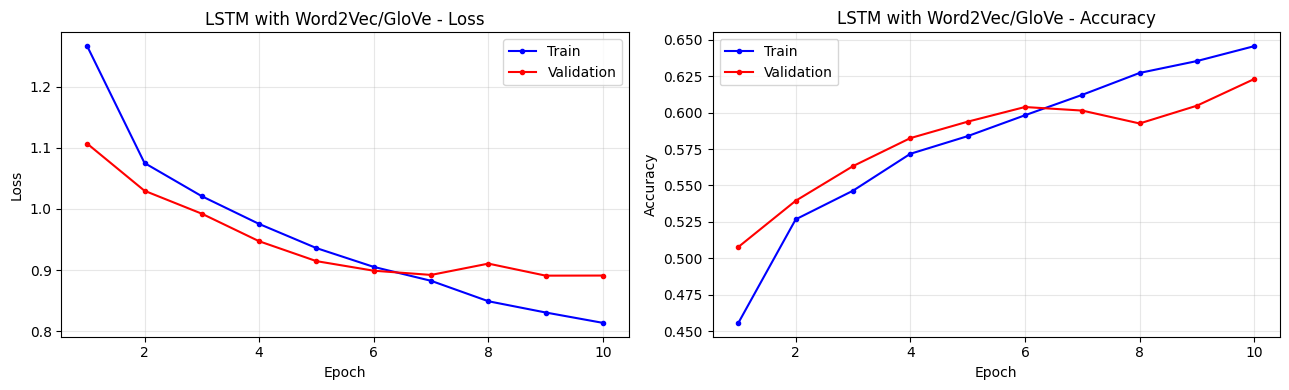

In [112]:

# -- Train LSTM + pretrained embedding model -------------------------------
t0 = time.time()
history_lstm_w2v = lstm_w2v_model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks('LSTM Word2Vec'),
    verbose=1
)
lstm_w2v_training_time = time.time() - t0

plot_history(history_lstm_w2v, 'LSTM with Word2Vec/GloVe', 'lstm_word2vec_curves.png')

LSTM + Word2Vec - Test Loss: 0.9143 | Test Accuracy: 0.5816

Classification Report:
              precision    recall  f1-score   support

    Rating 1     0.7366    0.4824    0.5830       284
    Rating 2     0.4027    0.4903    0.4422       359
    Rating 3     0.3459    0.1053    0.1614       437
    Rating 4     0.4631    0.6589    0.5439      1208
    Rating 5     0.7568    0.6786    0.7156      1811

    accuracy                         0.5816      4099
   macro avg     0.5410    0.4831    0.4892      4099
weighted avg     0.5940    0.5816    0.5728      4099



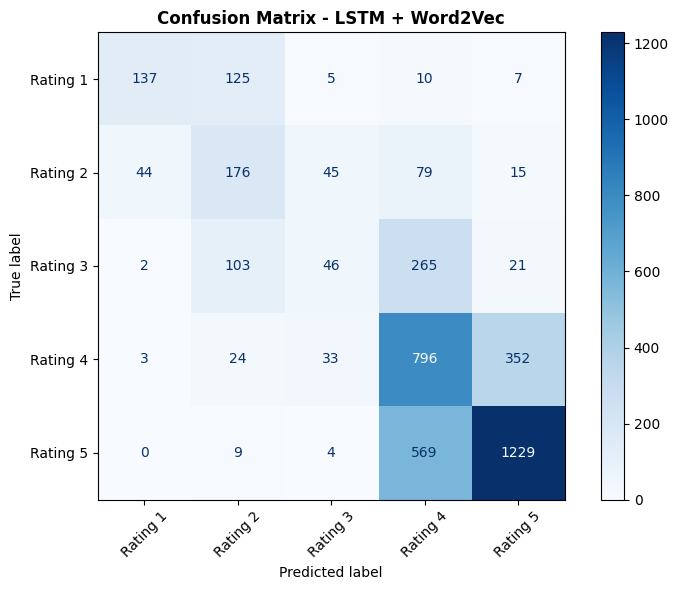

In [113]:

# -- Evaluate LSTM + pretrained embedding model ----------------------------
lstm_w2v_result, y_pred_lstm_w2v = evaluate_model(
    lstm_w2v_model,
    'LSTM + Word2Vec',
    lstm_w2v_training_time
)
results.append(lstm_w2v_result)
model_registry['LSTM + Word2Vec'] = lstm_w2v_model
history_registry['LSTM + Word2Vec'] = history_lstm_w2v
predictions_by_model['LSTM + Word2Vec'] = y_pred_lstm_w2v

plot_confusion(y_test, y_pred_lstm_w2v, 'Confusion Matrix - LSTM + Word2Vec', 'cm_lstm_word2vec.png')

---
## Section 9 - Model Comparison
*(Task 4.5.3)*

,Model,Test Loss,Test Accuracy,Training Time (min),Total Params,Trainable Params
0,LSTM,0.916071,0.601366,0.294053,1329733,1329733
1,LSTM + Word2Vec,0.914309,0.581605,0.536091,529765,29765
2,Simple RNN,1.075649,0.504269,0.417623,1292677,1292677


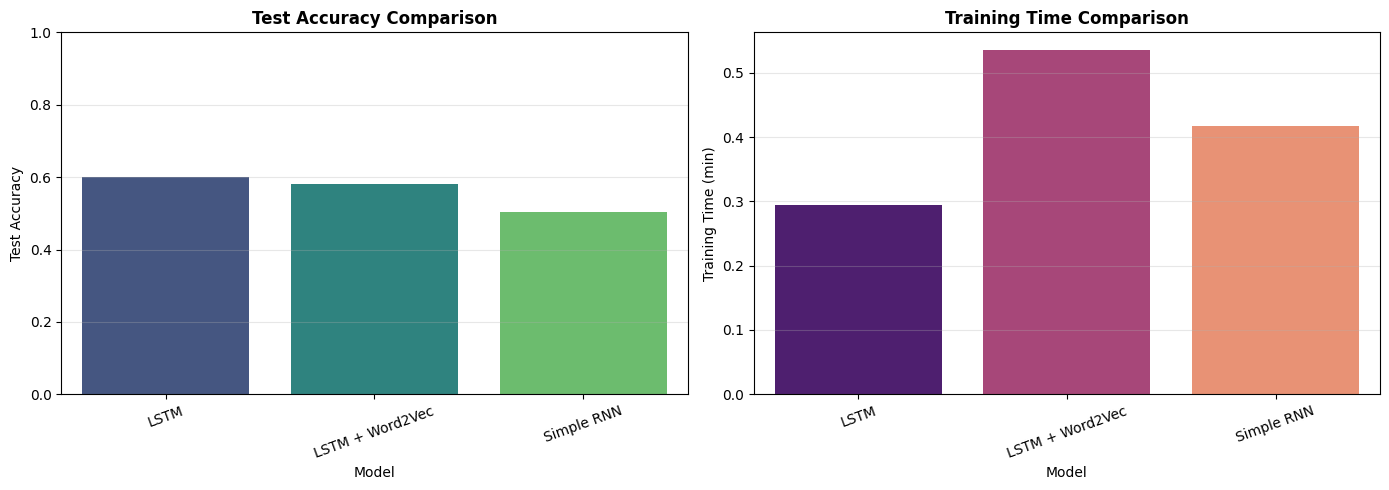

In [114]:

# -- Compare model performance and complexity ------------------------------
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='Test Accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='Model', y='Training Time (min)', ax=axes[1], palette='magma')
axes[1].set_title('Training Time Comparison', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('language_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 - Error Analysis
*(Task 4.5.4)*

In [115]:

# -- Select the best model based on test accuracy --------------------------
best_model_name = results_df.iloc[0]['Model']
best_model = model_registry[best_model_name]
best_predictions = predictions_by_model[best_model_name]

print(f'Best model selected for error analysis: {best_model_name}')

Best model selected for error analysis: LSTM


In [116]:

# -- Display 2-3 incorrect predictions -------------------------------------
incorrect_positions = np.where(best_predictions != y_test)[0]
print(f'Total incorrect predictions: {len(incorrect_positions)}')

sample_error_positions = incorrect_positions[:3]
error_rows = []

for pos in sample_error_positions:
    true_rating = label_encoder.inverse_transform([y_test[pos]])[0]
    pred_rating = label_encoder.inverse_transform([best_predictions[pos]])[0]
    probs = best_model.predict(X_test_pad[pos:pos+1], verbose=0)[0]
    confidence = float(np.max(probs))

    error_rows.append({
        'Original Review': test_original_reviews.iloc[pos][:400],
        'Cleaned Review': test_cleaned_reviews.iloc[pos][:400],
        'True Rating': true_rating,
        'Predicted Rating': pred_rating,
        'Prediction Confidence': confidence,
        'Cleaned Token Count': len(test_cleaned_reviews.iloc[pos].split())
    })

error_analysis_df = pd.DataFrame(error_rows)
display(error_analysis_df)

Total incorrect predictions: 1634


,Original Review,Cleaned Review,True Rating,Predicted Rating,Prediction Confidence,Cleaned Token Count
0,"nice hotel nice hotel good area explore, arriv...",nice hotel nice hotel good area explore arriva...,3,4,0.444826,77
1,"felt welcome location, location, location, wif...",felt welcome location location location wife s...,5,4,0.524690,75
2,"stayed hotel group friends, interesting mixed ...",stay hotel group friends interest mix view exp...,4,2,0.459144,90


In [117]:

# -- Model complexity vs performance table ---------------------------------
complexity_columns = [
    'Model',
    'Test Accuracy',
    'Test Loss',
    'Training Time (min)',
    'Total Params',
    'Trainable Params'
]
complexity_df = results_df[complexity_columns].copy()
display(complexity_df)

,Model,Test Accuracy,Test Loss,Training Time (min),Total Params,Trainable Params
0,LSTM,0.601366,0.916071,0.294053,1329733,1329733
1,LSTM + Word2Vec,0.581605,0.914309,0.536091,529765,29765
2,Simple RNN,0.504269,1.075649,0.417623,1292677,1292677


---
## Section 11 - Save Best Model and Prediction Utility

In [118]:

# -- Save the best model ----------------------------------------------------
best_model.save('best_hotel_review_rating_model.keras')
print(f'Saved best model: {best_model_name} -> best_hotel_review_rating_model.keras')

Saved best model: LSTM -> best_hotel_review_rating_model.keras


In [119]:

# -- Single-review prediction function -------------------------------------
def predict_rating(review_text, model=best_model):
    """Predict a hotel rating from raw review text."""
    cleaned = clean_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    probabilities = model.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_rating = label_encoder.inverse_transform([predicted_index])[0]
    confidence = float(np.max(probabilities))

    return {
        'cleaned_text': cleaned,
        'predicted_rating': predicted_rating,
        'confidence': confidence,
        'class_probabilities': dict(zip(class_names, probabilities.round(4)))
    }

# Example:
# predict_rating('The room was clean, staff were helpful, and the location was excellent.')

---
## Section 12 - Simple GUI for Real-Time Prediction
*(Task 4.5.5 - Optional GUI)*

In [121]:
# -- Gradio GUI for Real-Time Prediction -----------------------------------
# Gradio works in Kaggle, Colab and local environments without a display.

!pip install gradio -q

import gradio as gr

def gradio_predict(review_text):
    if not review_text.strip():
        return "Please enter a hotel review."
    
    prediction = predict_rating(review_text)
    
    stars = "⭐" * prediction['predicted_rating']
    
    output = f"""
🏨 Hotel Review Rating Prediction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Predicted Rating : {prediction['predicted_rating']} / 5  {stars}
Confidence       : {prediction['confidence']:.2%}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    """
    return output

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter your hotel review here...",
        label="Hotel Review"
    ),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🏨 Hotel Review Rating Predictor",
    description="Enter a hotel review and the model will predict its rating (1-5 stars).",
    examples=[
        ["The hotel was absolutely fantastic! Staff were incredibly helpful and the room was spotless."],
        ["Terrible experience. Room was dirty, staff were rude and the location was awful."],
        ["Average stay. Nothing special but nothing terrible either. Decent value for money."]
    ]
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6d742f11205b004d83.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


---
## Section 13 - Final Summary Printout

In [122]:

# -- Final results summary --------------------------------------------------
print('=' * 70)
print('FINAL LANGUAGE TASK RESULTS SUMMARY')
print('=' * 70)
print(results_df.to_string(index=False))
print('=' * 70)
print(f'Best model: {best_model_name}')

FINAL LANGUAGE TASK RESULTS SUMMARY
          Model  Test Loss  Test Accuracy  Training Time (min)  Total Params  Trainable Params
           LSTM   0.916071       0.601366             0.294053       1329733           1329733
LSTM + Word2Vec   0.914309       0.581605             0.536091        529765             29765
     Simple RNN   1.075649       0.504269             0.417623       1292677           1292677
Best model: LSTM
